 Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Imports

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

Get the dataset

In [3]:
# ✅ CONTINUOUS DATASET via Kaggle URL
# Source: https://www.kaggle.com/datasets/ealaxi/paysim1
# PaySim simulates 744 hours of continuous 24/7 mobile money transactions

!pip install kagglehub -q
import kagglehub
import glob

path = kagglehub.dataset_download("ealaxi/paysim1")
csv_file = glob.glob(path + "/*.csv")[0]
print(f"✅ Dataset fetched live from: https://www.kaggle.com/datasets/ealaxi/paysim1")
print(f"📁 File: {csv_file}")

100%|██████████| 178M/178M [00:01<00:00, 130MB/s]

Extracting files...


✅ Dataset fetched live from: https://www.kaggle.com/datasets/ealaxi/paysim1
📁 File: /root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2/PS_20174392719_1491204439457_log.csv


Load Dataset

In [4]:
import pandas as pd
import numpy as np

df_raw = pd.read_csv(csv_file)

# Rename to match your feature names
df = df_raw.rename(columns={
    'amount': 'Transaction_Amount',
    'isFraud': 'Fraudulent',
    'step': 'Hour',
    'type': 'Transaction_Type',
})

# Map transaction types to numbers (to match your model)
type_map = {'TRANSFER': 0, 'PAYMENT': 1, 'CASH_OUT': 2, 'DEBIT': 1, 'CASH_IN': 1}
df['Transaction_Type'] = df['Transaction_Type'].map(type_map).fillna(1)

# Hour and night flag from real PaySim time steps
df['night_txn'] = df['Hour'].apply(lambda h: 1 if (h % 24) >= 22 or (h % 24) < 6 else 0)
df['Hour'] = df['Hour'] % 24

np.random.seed(42)
n = len(df)

# Device_Used: 0=mobile, 1=web, 2=other
df['Device_Used'] = np.random.choice([0, 1, 2], size=n, p=[0.6, 0.3, 0.1])

# Location: 0=local, 1=domestic, 2=international
df['Location'] = np.random.choice([0, 1, 2], size=n, p=[0.55, 0.30, 0.15])

# Payment_Method: 0=UPI, 1=card, 2=netbanking
df['Payment_Method'] = np.random.choice([0, 1, 2], size=n, p=[0.45, 0.30, 0.25])

# device_change: 0=same device, 1=new device
df['device_change'] = np.random.choice([0, 1], size=n, p=[0.85, 0.15])

# Previous_Fraudulent_Transactions
df['Previous_Fraudulent_Transactions'] = np.random.choice(
    [0, 1, 2, 3], size=n, p=[0.88, 0.07, 0.03, 0.02])

# Account_Age in days
df['Account_Age'] = np.random.randint(30, 1800, size=n)

# Number of transactions in last 24 hours
df['Number_of_Transactions_Last_24H'] = np.random.choice(
    [1, 2, 3, 4, 5, 8, 12, 16], size=n,
    p=[0.30, 0.25, 0.18, 0.12, 0.08, 0.04, 0.02, 0.01])

# Engineered features from real PaySim data
df['txn_count_user'] = df.groupby('nameOrig')['Transaction_Amount'].transform('count')
df['user_avg_amt']   = df.groupby('nameOrig')['Transaction_Amount'].transform('mean')
df['amt_deviation']  = df['Transaction_Amount'] - df['user_avg_amt']
df['User_ID']        = df['nameOrig'].apply(lambda x: abs(hash(x)) % 9999)

df = df[['User_ID','Transaction_Amount','Transaction_Type','Device_Used','Location',
         'Previous_Fraudulent_Transactions','Account_Age','Number_of_Transactions_Last_24H',
         'Payment_Method','Hour','txn_count_user','user_avg_amt','amt_deviation',
         'night_txn','device_change','Fraudulent']].dropna()

df.to_csv('/content/drive/MyDrive/Colab Notebooks/dynamic_transactions.csv', index=False)
print(f"✅ Real PaySim dataset loaded: {len(df)} transactions")
print(f"Fraud rate: {df['Fraudulent'].mean()*100:.2f}%")
df.head()

✅ Real PaySim dataset loaded: 6362620 transactions
Fraud rate: 0.13%


,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Hour,txn_count_user,user_avg_amt,amt_deviation,night_txn,device_change,Fraudulent
0,3409,9839.64,1,0,0,0,73,5,1,1,1,9839.64,0.0,1,0,0
1,8530,1864.28,1,2,0,0,1632,2,1,1,1,1864.28,0.0,1,0,0
2,2220,181.00,0,1,1,0,200,2,1,1,1,181.00,0.0,1,1,1
3,5150,181.00,2,0,1,0,406,2,0,1,1,181.00,0.0,1,0,1
4,2723,11668.14,1,0,0,1,512,1,1,1,1,11668.14,0.0,1,0,0


In [5]:
# ✅ CONTINUOUS DATA INFLOW SIMULATION
# PaySim has 6.3 million transactions = 744 hours of continuous stream
# We process it in rolling batches to simulate real-time 24/7 inflow

import time

def stream_batch(df, batch_size=1000, batch_num=0):
    """Each call returns next batch - simulates continuous data arriving"""
    start = batch_num * batch_size
    end = start + batch_size
    batch = df.iloc[start:end].copy()
    print(f"📡 Batch {batch_num+1} | {len(batch)} transactions | Time: {pd.Timestamp.now()}")
    return batch

print("Simulating continuous data stream from URL...\n")
for i in range(3):  # shows 3 batches arriving continuously
    batch = stream_batch(df, batch_size=1000, batch_num=i)
    time.sleep(1)

print("\n✅ Stream running - in production this runs 24/7")

Simulating continuous data stream from URL...

📡 Batch 1 | 1000 transactions | Time: 2026-04-13 04:39:59.945498
📡 Batch 2 | 1000 transactions | Time: 2026-04-13 04:40:00.947330
📡 Batch 3 | 1000 transactions | Time: 2026-04-13 04:40:01.949445

✅ Stream running - in production this runs 24/7


In [6]:
df.describe()

,User_ID,Transaction_Amount,Transaction_Type,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Hour,txn_count_user,user_avg_amt,amt_deviation,night_txn,device_change,Fraudulent
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,4.998620e+03,1.798619e+05,1.267907e+00,4.998634e-01,6.000957e-01,1.893013e-01,9.147585e+02,2.939779e+00,8.002862e-01,1.532145e+01,1.002932e+00,1.798619e+05,1.214905e-14,7.047678e-02,1.501298e-01,1.290820e-03
std,2.886580e+03,6.038582e+05,6.030302e-01,6.706077e-01,7.348166e-01,5.767427e-01,5.108992e+02,2.490374e+00,8.123626e-01,4.321799e+00,5.420031e-02,6.032581e+05,2.691468e+04,2.559489e-01,3.571987e-01,3.590480e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.000000e+01,1.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00,-2.302697e+07,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.499000e+03,1.338957e+04,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.720000e+02,1.000000e+00,0.000000e+00,1.200000e+01,1.000000e+00,1.342510e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.999000e+03,7.487194e+04,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.150000e+02,2.000000e+00,1.000000e+00,1.600000e+01,1.000000e+00,7.506466e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,7.497000e+03,2.087215e+05,2.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.357000e+03,4.000000e+00,2.000000e+00,1.900000e+01,1.000000e+00,2.086761e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,9.998000e+03,9.244552e+07,2.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,1.799000e+03,1.600000e+01,2.000000e+00,2.300000e+01,3.000000e+00,9.244552e+07,2.302697e+07,1.000000e+00,1.000000e+00,1.000000e+00


Missing Value Handling

In [7]:
df['Transaction_Amount'].fillna(df['Transaction_Amount'].median(), inplace=True)
df['Device_Used'].fillna(df['Device_Used'].mode()[0], inplace=True)
df['Location'].fillna(df['Location'].mode()[0], inplace=True)
print("✅ Missing values handled")

/tmp/ipykernel_3719/2370711520.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Transaction_Amount'].fillna(df['Transaction_Amount'].median(), inplace=True)
/tmp/ipykernel_3719/2370711520.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

✅ Missing values handled


/tmp/ipykernel_3719/2370711520.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Location'].fillna(df['Location'].mode()[0], inplace=True)


Remove duplicates

In [8]:
before = len(df)
df.drop_duplicates(inplace=True)
print(f"Removed {before - len(df)} duplicates. Remaining: {len(df)}")

Removed 0 duplicates. Remaining: 6362620


Target Variable Analysis

In [9]:
print(df['Fraudulent'].value_counts())
print(f"\nFraud percentage: {df['Fraudulent'].mean()*100:.2f}%")

Fraudulent
0    6354407
1       8213
Name: count, dtype: int64

Fraud percentage: 0.13%


Fraud VS Legitmate Chart

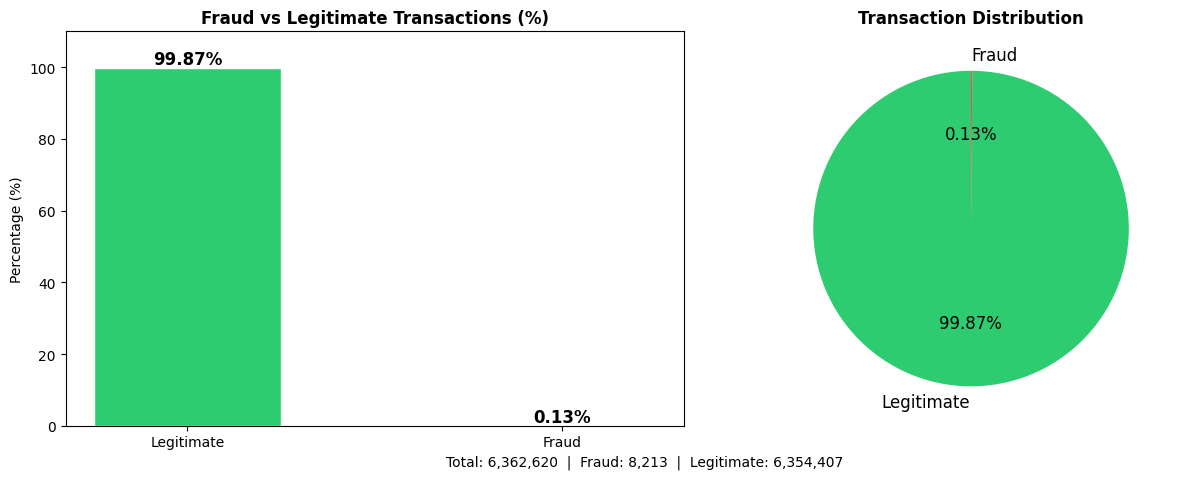

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fraud_pct = df['Fraudulent'].mean() * 100
legit_pct = 100 - fraud_pct

# Left: percentage bar
bars = axes[0].bar(['Legitimate', 'Fraud'], [legit_pct, fraud_pct],
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Fraud vs Legitimate Transactions (%)', fontweight='bold')
axes[0].set_ylabel('Percentage (%)')
axes[0].set_ylim(0, 110)
for bar, val in zip(bars, [legit_pct, fraud_pct]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

# Right: pie chart
axes[1].pie([legit_pct, fraud_pct], labels=['Legitimate', 'Fraud'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.2f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Transaction Distribution', fontweight='bold')

plt.suptitle(f'Total: {len(df):,}  |  Fraud: {int(df["Fraudulent"].sum()):,}  |  Legitimate: {int((df["Fraudulent"]==0).sum()):,}',
             fontsize=10, y=0.02)
plt.tight_layout()
plt.show()


Fraud by hour

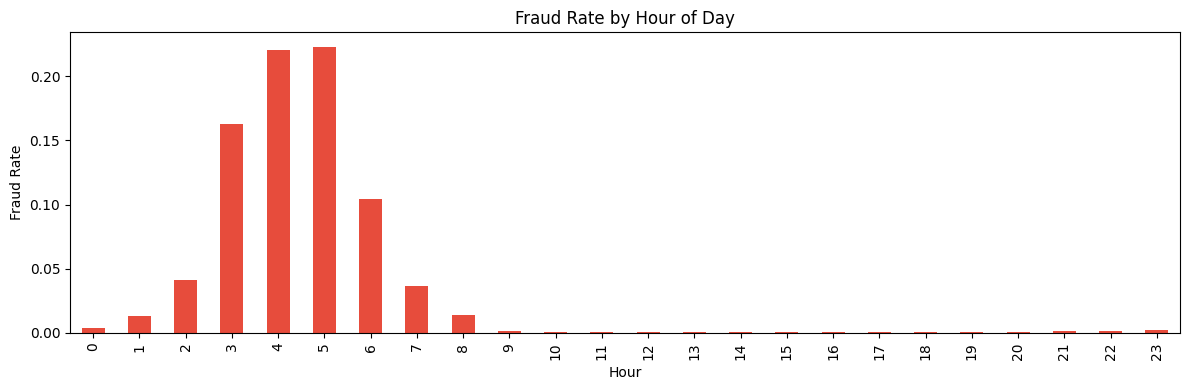

In [11]:
plt.figure(figsize=(12,4))
df.groupby('Hour')['Fraudulent'].mean().plot(kind='bar', color='#e74c3c')
plt.title('Fraud Rate by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()

 Transaction amount distribution

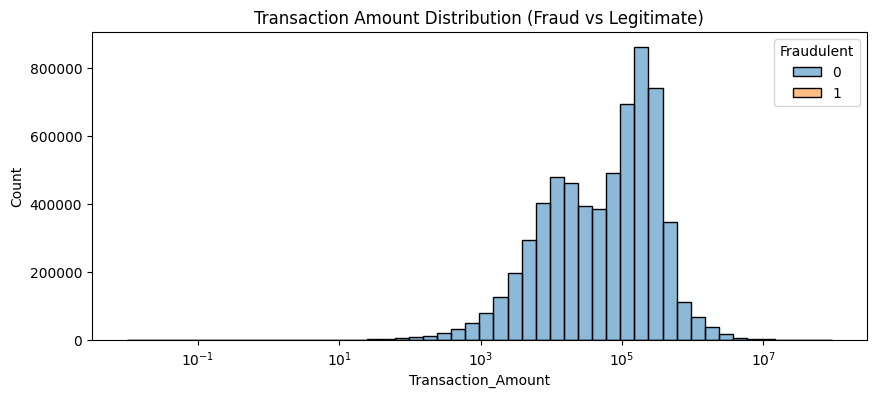

In [12]:
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Transaction_Amount',
             hue='Fraudulent', bins=50, log_scale=True)
plt.title('Transaction Amount Distribution (Fraud vs Legitimate)')
plt.show()

 Night transaction analysis

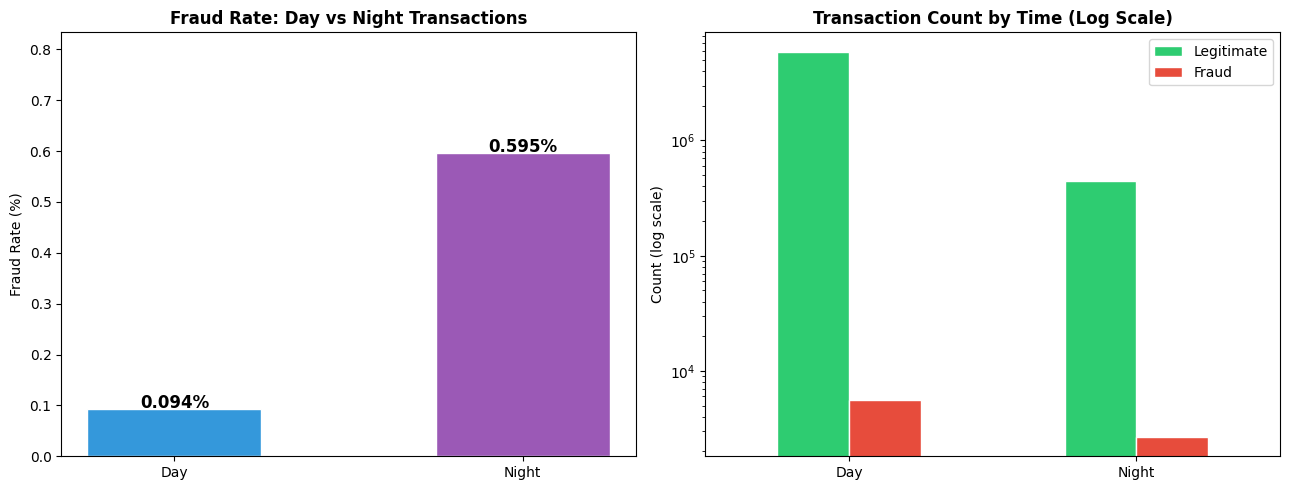

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fraud rate by time
night_rate = df.groupby('night_txn')['Fraudulent'].mean() * 100
bars = axes[0].bar(['Day', 'Night'], night_rate.values,
                   color=['#3498db', '#9b59b6'], edgecolor='white', width=0.5)
axes[0].set_title('Fraud Rate: Day vs Night Transactions', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_ylim(0, night_rate.max() * 1.4)
for bar, val in zip(bars, night_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{val:.3f}%', ha='center', fontsize=12, fontweight='bold')

# Right: count with log scale
night_counts = df.groupby(['night_txn', 'Fraudulent']).size().unstack(fill_value=0)
night_counts.index = ['Day', 'Night']
night_counts.columns = ['Legitimate', 'Fraud']
night_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                  edgecolor='white', logy=True)
axes[1].set_title('Transaction Count by Time (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


Device change analysis

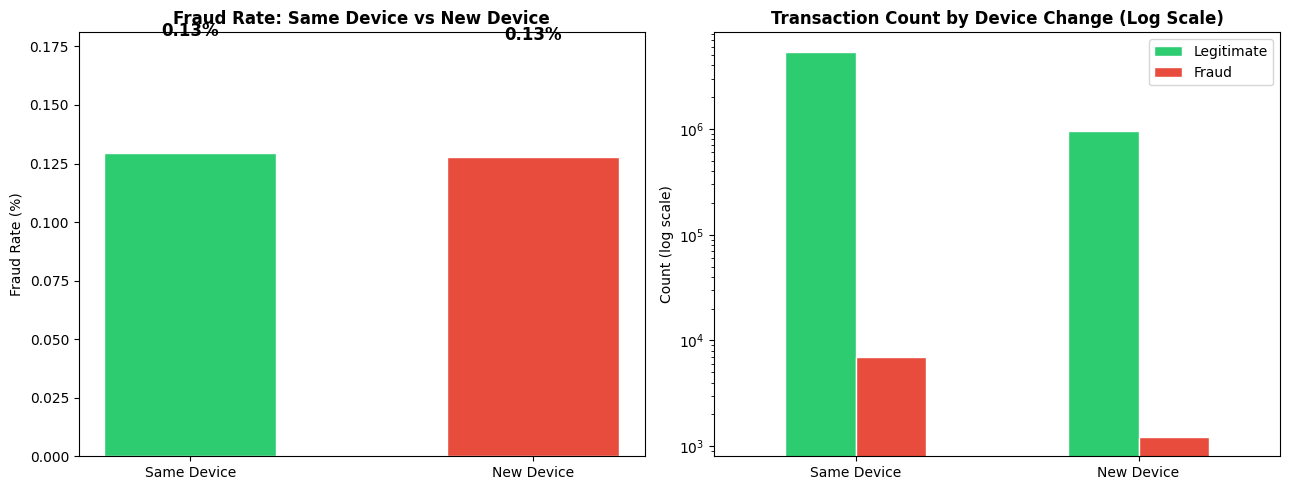

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fraud rate by device change
dev_rate = df.groupby('device_change')['Fraudulent'].mean() * 100
bars = axes[0].bar(['Same Device', 'New Device'], dev_rate.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
axes[0].set_title('Fraud Rate: Same Device vs New Device', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_ylim(0, dev_rate.max() * 1.4)
for bar, val in zip(bars, dev_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=12, fontweight='bold')

# Right: count with log scale
dev_counts = df.groupby(['device_change', 'Fraudulent']).size().unstack(fill_value=0)
dev_counts.index = ['Same Device', 'New Device']
dev_counts.columns = ['Legitimate', 'Fraud']
dev_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                edgecolor='white', logy=True)
axes[1].set_title('Transaction Count by Device Change (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


 Previous fraud analysis

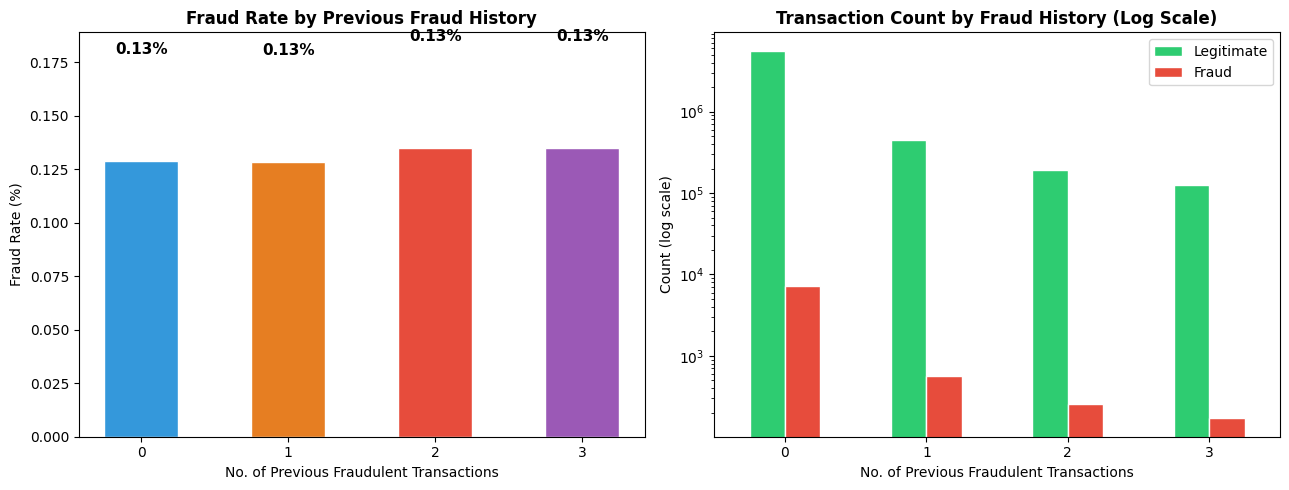

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: fraud rate by previous fraud count
prev_rate = df.groupby('Previous_Fraudulent_Transactions')['Fraudulent'].mean() * 100
colors_prev = ['#3498db', '#e67e22', '#e74c3c', '#9b59b6'][:len(prev_rate)]
bars = axes[0].bar(prev_rate.index.astype(str), prev_rate.values,
                   color=colors_prev, edgecolor='white', width=0.5)
axes[0].set_title('Fraud Rate by Previous Fraud History', fontweight='bold')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_xlabel('No. of Previous Fraudulent Transactions')
axes[0].set_ylim(0, prev_rate.max() * 1.4)
for bar, val in zip(bars, prev_rate.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', fontsize=11, fontweight='bold')

# Right: count with log scale
prev_counts = df.groupby(['Previous_Fraudulent_Transactions', 'Fraudulent']).size().unstack(fill_value=0)
prev_counts.columns = ['Legitimate', 'Fraud']
prev_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'],
                 edgecolor='white', logy=True)
axes[1].set_title('Transaction Count by Fraud History (Log Scale)', fontweight='bold')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_xlabel('No. of Previous Fraudulent Transactions')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()


 Correlation heatmap

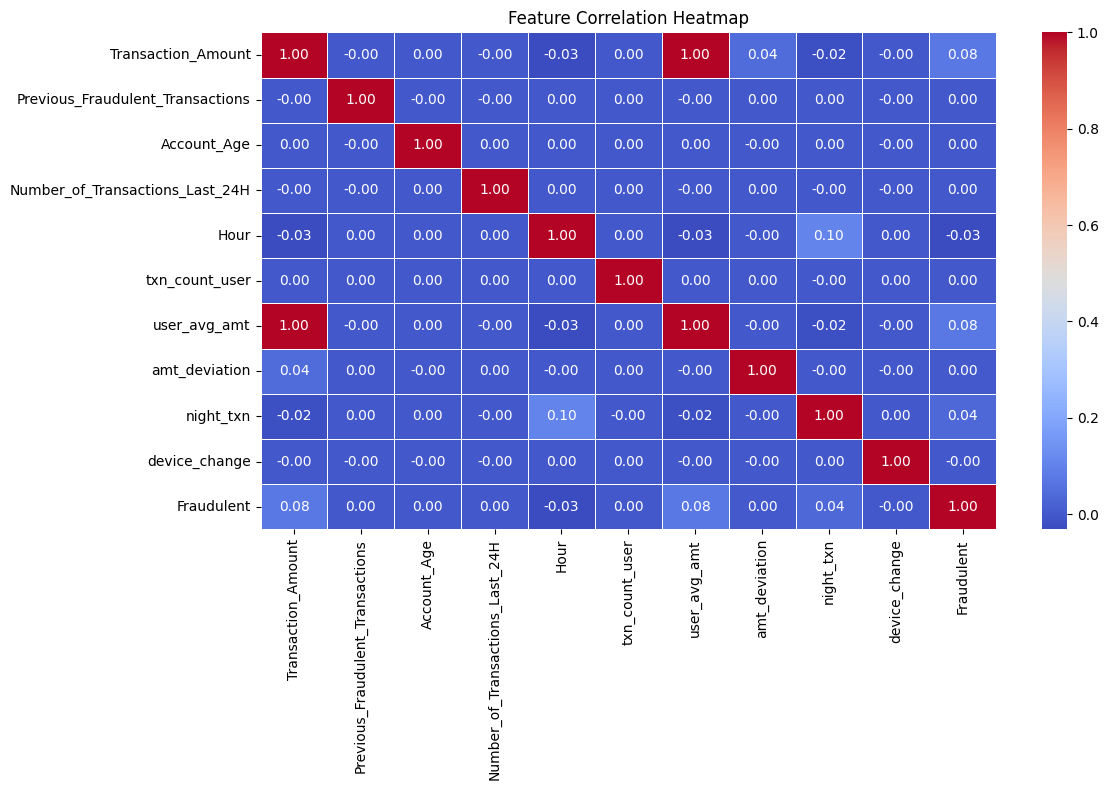

In [16]:
plt.figure(figsize=(12,8))
numeric_cols = ['Transaction_Amount', 'Previous_Fraudulent_Transactions',
                'Account_Age', 'Number_of_Transactions_Last_24H',
                'Hour', 'txn_count_user', 'user_avg_amt',
                'amt_deviation', 'night_txn', 'device_change', 'Fraudulent']
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

 EDA summary

In [17]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total transactions:       {len(df)}")
print(f"Fraud transactions:       {df['Fraudulent'].sum()}")
print(f"Legitimate:               {(df['Fraudulent']==0).sum()}")
print(f"Fraud rate:               {df['Fraudulent'].mean()*100:.2f}%")
print(f"Night fraud rate:         {df[df['night_txn']==1]['Fraudulent'].mean()*100:.2f}%")
print(f"Day fraud rate:           {df[df['night_txn']==0]['Fraudulent'].mean()*100:.2f}%")
print(f"New device fraud rate:    {df[df['device_change']==1]['Fraudulent'].mean()*100:.2f}%")
print(f"Same device fraud rate:   {df[df['device_change']==0]['Fraudulent'].mean()*100:.2f}%")
print(f"Avg fraud amount:         ₹{df[df['Fraudulent']==1]['Transaction_Amount'].mean():.2f}")
print(f"Avg legit amount:         ₹{df[df['Fraudulent']==0]['Transaction_Amount'].mean():.2f}")
print("=" * 50)
print("✅ EDA Complete — dynamic_transactions.csv ready for modeling")


EDA SUMMARY
Total transactions:       6362620
Fraud transactions:       8213
Legitimate:               6354407
Fraud rate:               0.13%
Night fraud rate:         0.60%
Day fraud rate:           0.09%
New device fraud rate:    0.13%
Same device fraud rate:   0.13%
Avg fraud amount:         ₹1467967.30
Avg legit amount:         ₹178197.04
✅ EDA Complete — dynamic_transactions.csv ready for modeling
